# 02. Извлечение и отбор признаков

**Цель:** решить, какие признаки действительно нужны модели, и собрать итоговый воспроизводимый препроцессор.

 *два-три осмысленных признака из предметной области почти всегда лучше автоматической генерации*. Обратное тоже верно: признак, который **дублирует** уже имеющуюся информацию, ничего не добавляет. Он только раздувает матрицу, мешает линейным моделям из-за мультиколлинеарности и усложняет интерпретацию.

План:
1. Сконструировать признаки;
2. найти, от чего на самом деле зависит урожайность с гектара;
3. собрать три варианта препроцессора и **честно** сравнить их на кросс-валидации;
4. сохранить победителя.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from modules import plots
from modules.transformers import (
    TARGET, AREA_COL, TRASH_COL, NUMERIC_COLS, CATEGORICAL_COLS, CATEGORICAL_ALL_COLS,
    AGRO_INPUT_COLS, WEATHER_COLS, WATER_COLS, WIND_DIRECTION_COLS,
    PaddyFeatureGenerator, clean_column_names, make_column_cleaner,
)

RANDOM_STATE = 42
DATA_DIR = Path("data")
MODELS_DIR = Path("models")
plots.setup_style()

train_df = pd.read_csv(DATA_DIR / "train.csv")
X, y = train_df.drop(columns=[TARGET]), train_df[TARGET]
print(f"train: {X.shape[0]} строк, {X.shape[1]} исходных колонок")

train: 1870 строк, 44 исходных колонок


## 1. Признаки

In [ ]:
generator = Pipeline([
    ("clean", make_column_cleaner()), 
    ("features", PaddyFeatureGenerator())
])
F = generator.fit_transform(X)
new_cols = [c for c in F.columns if c not in clean_column_names(X).columns]
print("Новые признаки:", new_cols)

# Признаки «на гектар»
per_ha = F[AGRO_INPUT_COLS + [TRASH_COL]].div(F[AREA_COL], axis=0).round(3)
pd.DataFrame({"уникальных значений": per_ha.nunique(), "значение на 1 га": per_ha.iloc[0]})

Новые признаки: ['trash_per_ha', 'total_irrigation_mm', 'total_drain_mm', 'water_balance_mm', 'avg_min_temp', 'avg_max_temp', 'avg_temp_range', 'avg_wind_speed', 'avg_humidity']


,уникальных значений,значение на 1 га
Seedrate(in Kg),1,25.00
LP_Mainfield(in Tonnes),1,12.50
Nursery area (Cents),1,20.00
LP_nurseryarea(in Tonnes),1,1.00
DAP_20days,1,40.00
Weed28D_thiobencarb,1,2.00
Urea_40Days,1,27.13
Potassh_50Days,1,10.38
Micronutrients_70Days,1,15.00
Pest_60Day(in ml),1,600.00


### 1.1. `seedrate_per_ha`, `nursery_area_per_ha` и т. п. — константы

Норма высева на гектар **всегда 25 кг**, питомник — 20 центов на гектар и т. д. Признак с одним значением не несёт информации.

Единственное исключение — `trash_per_ha` (3 значения). Проверим, что оно означает:

In [14]:
pd.crosstab(F["trash_per_ha"], F["Variety"])

Variety,CO_43,delux ponni,ponmani
trash_per_ha,,,
80.0,0,668,0
90.0,490,0,0
100.0,0,1,711


### 1.2. `trash_per_ha` зависит от сорта риса

80 связок/га — `delux ponni`, 90 — `CO_43`, 100 — `ponmani` (одна строка-исключение). Растительные остатки — следствие сорта, а не новая информация. One-hot по `Variety` уже содержит всё то же самое.

### 1.3. Погодные и водные агрегаты — это агроблок

In [4]:
agg_cols = ["avg_min_temp", "avg_max_temp", "avg_humidity", "avg_wind_speed", "total_irrigation_mm", "water_balance_mm"]
by_block = F.groupby("Agriblock")[agg_cols]
print("Уникальных значений агрегатов внутри одного блока (максимум):", by_block.nunique().to_numpy().max())
by_block.first().round(1)

Уникальных значений агрегатов внутри одного блока (максимум): 1


,avg_min_temp,avg_max_temp,avg_humidity,avg_wind_speed,total_irrigation_mm,water_balance_mm
Agriblock,,,,,,
Chinnasalem,15.9,32.4,84.6,7.5,610.0,180.0
Cuddalore,16.5,32.0,80.8,8.0,605.2,170.4
Kallakurichi,17.0,32.2,87.1,7.0,611.0,182.0
Kurinjipadi,17.8,33.0,80.2,7.5,605.2,170.4
Panruti,18.4,32.9,86.0,8.0,611.0,182.0
Sankarapuram,18.1,32.2,81.9,11.0,610.0,180.0


Каждый агрегат внутри блока — константа. Средняя температура или водный баланс — лишь другой способ закодировать `Agriblock`. Для модели, которая уже видит one-hot `Agriblock_*`, это не новые данные.

## 2. От чего на самом деле зависит урожайность с гектара

После удаления дублей остаются **5 информативных колонок**: `Hectares`, `Agriblock`, `Variety`, `Soil Types`, `Nursery`. Проверим, что они несут *ту же информацию*, что и все 44 исходные. Для этого сравним, на сколько групп одинаковых строк разбивают данные оба набора:

In [5]:
Xc = clean_column_names(X)
all_cols = NUMERIC_COLS + CATEGORICAL_ALL_COLS
compact_cols = [AREA_COL] + CATEGORICAL_COLS

n_all = Xc.groupby(all_cols).ngroups
n_compact = Xc.groupby(compact_cols).ngroups
print(
    f"Групп одинаковых объектов: все {len(all_cols)} колонки → {n_all},",
    f"{len(compact_cols)} колонок → {n_compact}"  
)

Групп одинаковых объектов: все 44 колонки → 404, 5 колонок → 403


Число групп почти совпадает (разница — та единственная строка-исключение с `trash_per_ha`). Все остальные колонки ничего не различают сверх этих пяти.

Теперь посмотрим, **как** урожайность с гектара зависит от площади:

Hectares,1,2,3,4,5,6
mean,5755.0,5732.0,5743.0,6119.0,6203.0,6040.0
std,161.0,165.0,166.0,257.0,175.0,271.0
count,172.0,268.0,308.0,436.0,529.0,157.0


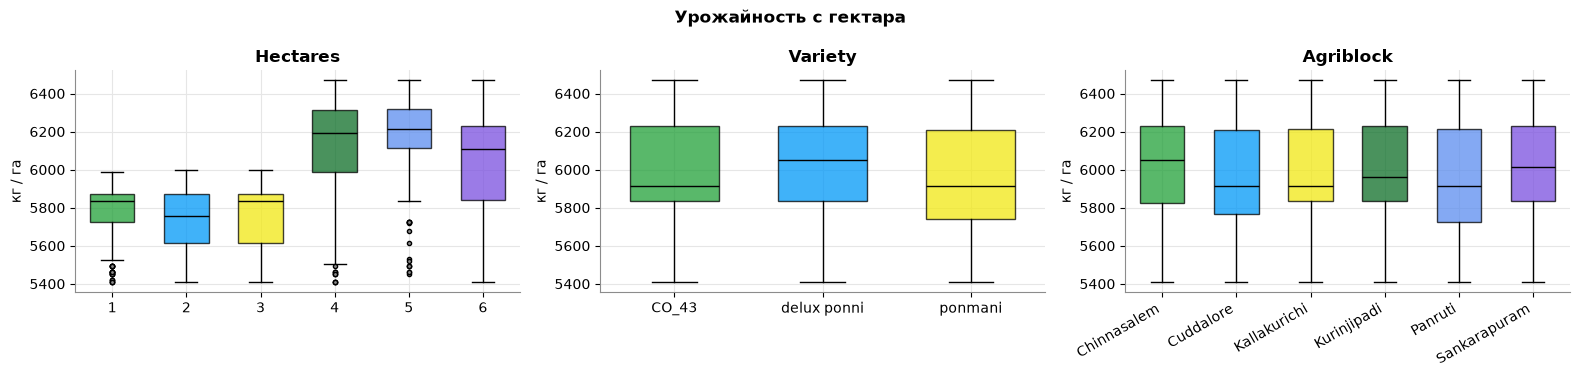

In [6]:
frame = Xc[compact_cols].assign(yield_per_ha=y.to_numpy() / Xc[AREA_COL].to_numpy())
display(frame.groupby(AREA_COL)["yield_per_ha"].agg(["mean", "std", "count"]).round(0).T)
plots.plot_box_by(
    frame, "yield_per_ha", [AREA_COL, "Variety", "Agriblock"], ncols=3,
    ylabel="кг / га", title="Урожайность с гектара"
)

Зависимость от площади **ступенчатая и немонотонная**: 1–3 га — около 5 740 кг/га, 4–5 га — 6 100–6 200, 6 га — снова ниже. Линейная модель с одним числовым `Hectares` такую форму не поймает.

Вторая идея — **моделировать урожайность с гектара**, а не общий урожай.

## 3. Три варианта препроцессора

| Вариант | Что внутри | Признаков |
|---|---|---|
| `base` | пайплайн из ноутбука 01: все 44 колонки | 71 |
| `generated` | `base` + новые признаки (`PaddyFeatureGenerator`) | 80 |
| `compact` | `Hectares` (число) + `Hectares` (категория) + 4 категориальных | 20 |

In [8]:
def numeric_pipe():
    return Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])


def categorical_pipe():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])


prep_base = joblib.load(MODELS_DIR / "preprocessor_base.joblib")   # из ноутбука 01

prep_generated = Pipeline([
    ("clean", make_column_cleaner()),
    ("features", PaddyFeatureGenerator()),
    ("prep", ColumnTransformer([
        ("num", numeric_pipe(), NUMERIC_COLS + PaddyFeatureGenerator().new_columns()),
        ("cat", categorical_pipe(), CATEGORICAL_ALL_COLS),
    ], remainder="drop")),
]).set_output(transform="pandas")

prep_compact = Pipeline([
    ("clean", make_column_cleaner()),
    ("prep", ColumnTransformer([
        ("area", numeric_pipe(), [AREA_COL]),
        ("area_cat", categorical_pipe(), [AREA_COL]),
        ("cat", categorical_pipe(), CATEGORICAL_COLS),
    ], remainder="drop")),
]).set_output(transform="pandas")

variants = {"base": prep_base, "generated": prep_generated, "compact": prep_compact}
for name, prep in variants.items():
    print(f"{name:10s} → {prep.fit_transform(X).shape[1]:3d} признаков")

base       →  71 признаков
generated  →  80 признаков
compact    →  20 признаков


In [9]:
prep_compact.fit_transform(X).head(3)

,area__Hectares,area_cat__Hectares_1,area_cat__Hectares_2,area_cat__Hectares_3,area_cat__Hectares_4,area_cat__Hectares_5,area_cat__Hectares_6,cat__Agriblock_Chinnasalem,cat__Agriblock_Cuddalore,cat__Agriblock_Kallakurichi,cat__Agriblock_Kurinjipadi,cat__Agriblock_Panruti,cat__Agriblock_Sankarapuram,cat__Variety_CO_43,cat__Variety_delux ponni,cat__Variety_ponmani,cat__Soil Types_alluvial,cat__Soil Types_clay,cat__Nursery_dry,cat__Nursery_wet
0,1.567909,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.567909,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
2,1.567909,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


## 4. Честное сравнение: препроцессор как гиперпараметр

Перебираем **сам шаг** `prep` (и модель) в `GridSearchCV`. На каждом из 5 фолдов весь пайплайн клонируется и обучается заново только на обучающей части фолда, поэтому утечки нет.

Две модели с разным подходом:
* `Ridge` — линейная, чувствительна к форме признаков;
* `GradientBoostingRegressor` — деревья, сами находят пороги и взаимодействия.

In [11]:
search = GridSearchCV(
    Pipeline([("prep", prep_compact), ("model", Ridge())]),
    param_grid={
        "prep": list(variants.values()),
        "model": [Ridge(alpha=1.0), GradientBoostingRegressor(random_state=RANDOM_STATE)],
    },
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring={"MAE": "neg_mean_absolute_error", "R2": "r2"},
    refit=False,
    n_jobs=-1,
)
search.fit(X, y)

name_of = {id(v): k for k, v in variants.items()}
res = pd.DataFrame(search.cv_results_)
comparison = pd.DataFrame({
    "prep": [name_of[id(p)] for p in res["param_prep"]],
    "model": [type(m).__name__.replace("Regressor", "") for m in res["param_model"]],
    "MAE": -res["mean_test_MAE"],
    "MAE_std": res["std_test_MAE"],
    "R2": res["mean_test_R2"],
})
comparison["вариант"] = comparison["prep"] + " + " + comparison["model"]
comparison.sort_values("MAE").round(4)

,prep,model,MAE,MAE_std,R2,вариант
4,generated,GradientBoosting,600.2475,19.4827,0.9918,generated + GradientBoosting
3,base,GradientBoosting,600.8106,20.5147,0.9918,base + GradientBoosting
5,compact,GradientBoosting,603.8124,23.4061,0.9918,compact + GradientBoosting
2,compact,Ridge,615.9179,22.7020,0.9913,compact + Ridge
0,base,Ridge,732.3473,23.0276,0.9892,base + Ridge
1,generated,Ridge,732.3936,23.0436,0.9892,generated + Ridge


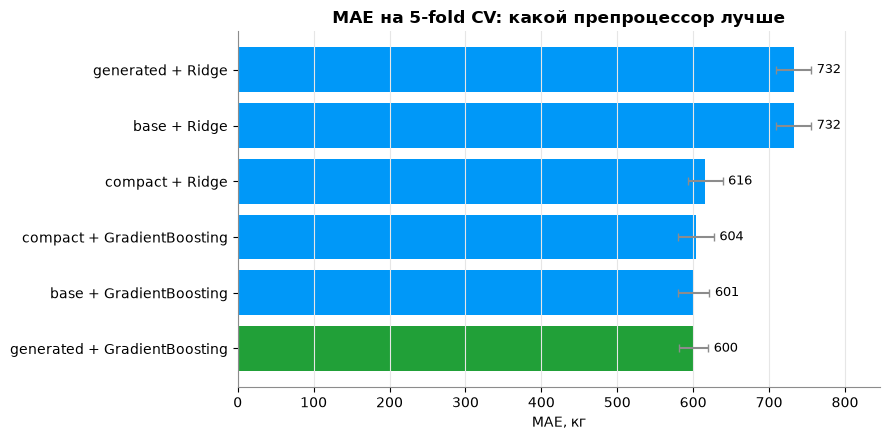

In [12]:
plots.plot_cv_comparison(
    comparison, "вариант", "MAE", "MAE_std",
    title="MAE на 5-fold CV: какой препроцессор лучше"
)

## 5. Выводы по признакам

* **`compact` даёт то же или лучшее качество при вчетверо меньшем числе признаков (20 против 71–80).**
  * Для `Ridge` выигрыш большой: MAE 616 против 732 кг.
  * Для бустинга разница в пределах шума. Деревья и так умели находить пороги по `Hectares`.
* **Новые признаки качества не добавили.** Это ожидаемо: они константы или переодетые `Variety`/`Agriblock`.
* R² у всех вариантов ≈ 0.99 и почти не различается. Высокий R² здесь «дарит» площадь, поэтому главная метрика дальше — **MAE в кг**.

In [13]:
prep_compact.fit(X, y)
joblib.dump(prep_compact, MODELS_DIR / "preprocessor_fe.joblib")
feature_names = prep_compact.get_feature_names_out()
pd.Series(feature_names, name="feature").to_csv(MODELS_DIR / "feature_names.csv", index=False)
print(f"Сохранено: preprocessor_fe.joblib, {len(feature_names)} признаков")
print(list(feature_names))

Сохранено: preprocessor_fe.joblib, 20 признаков
['area__Hectares', 'area_cat__Hectares_1', 'area_cat__Hectares_2', 'area_cat__Hectares_3', 'area_cat__Hectares_4', 'area_cat__Hectares_5', 'area_cat__Hectares_6', 'cat__Agriblock_Chinnasalem', 'cat__Agriblock_Cuddalore', 'cat__Agriblock_Kallakurichi', 'cat__Agriblock_Kurinjipadi', 'cat__Agriblock_Panruti', 'cat__Agriblock_Sankarapuram', 'cat__Variety_CO_43', 'cat__Variety_delux ponni', 'cat__Variety_ponmani', 'cat__Soil Types_alluvial', 'cat__Soil Types_clay', 'cat__Nursery_dry', 'cat__Nursery_wet']
